In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

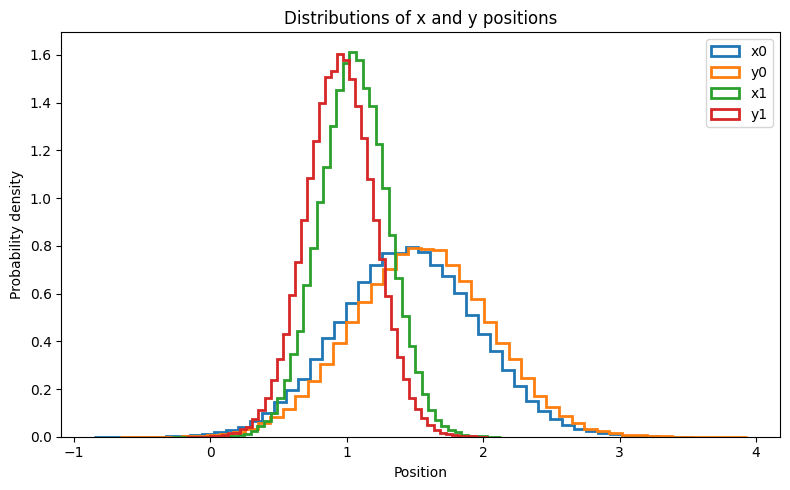

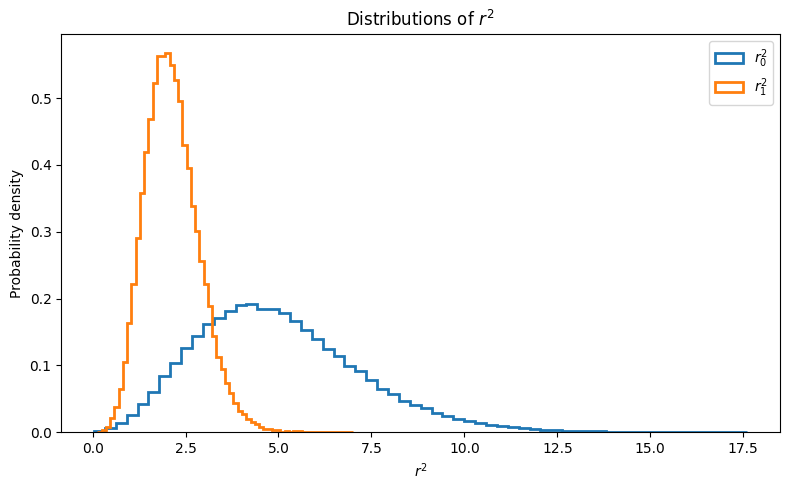

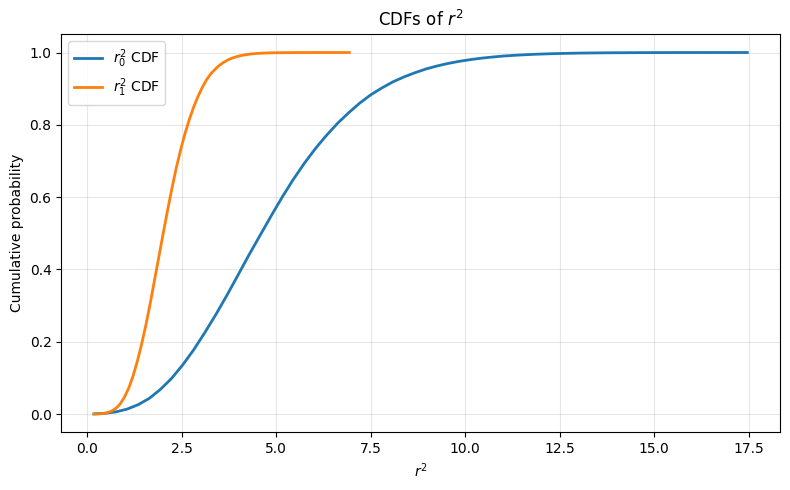

In [2]:
# -----------------------
# Parameters
# -----------------------
N0 = int(1e5)
N1 = int(1e5)

x0, y0 = 1.45, 1.55
x1, y1 = 1.05, 0.95

sigma0 = 0.5
sigma1 = 0.25

# -----------------------
# Generate data
# -----------------------
posx0 = np.random.normal(x0, sigma0, size=N0)
posy0 = np.random.normal(y0, sigma0, size=N0)

posx1 = np.random.normal(x1, sigma1, size=N1)
posy1 = np.random.normal(y1, sigma1, size=N1)

r02 = posx0**2 + posy0**2
r12 = posx1**2 + posy1**2

# -----------------------
# 1D position histograms (STEP-LIKE)
# -----------------------
plt.figure(figsize=(8, 5))
plt.hist(posx0, bins=50, histtype="step", lw=2, label="x0", density=True)
plt.hist(posy0, bins=50, histtype="step", lw=2, label="y0", density=True)
plt.hist(posx1, bins=50, histtype="step", lw=2, label="x1", density=True)
plt.hist(posy1, bins=50, histtype="step", lw=2, label="y1", density=True)
plt.xlabel("Position")
plt.ylabel("Probability density")
plt.title("Distributions of x and y positions")
plt.legend()
plt.tight_layout()

# -----------------------
# r^2 histograms (STEP-LIKE)
# -----------------------
plt.figure(figsize=(8, 5))
plt.hist(r02, bins=60, histtype="step", lw=2, label=r"$r_0^2$", density=True)
plt.hist(r12, bins=60, histtype="step", lw=2, label=r"$r_1^2$", density=True)
plt.xlabel(r"$r^2$")
plt.ylabel("Probability density")
plt.title(r"Distributions of $r^2$")
plt.legend()
plt.tight_layout()

# -----------------------
# PDFs
# -----------------------
hist0, bins_edges0 = np.histogram(r02, bins=60, density=True)
bins0 = 0.5 * (bins_edges0[:-1] + bins_edges0[1:])

hist1, bins_edges1 = np.histogram(r12, bins=60, density=True)
bins1 = 0.5 * (bins_edges1[:-1] + bins_edges1[1:])

# -----------------------
# CDFs
# -----------------------
cdf0 = np.cumsum(hist0)
cdf0 /= cdf0[-1]

cdf1 = np.cumsum(hist1)
cdf1 /= cdf1[-1]

plt.figure(figsize=(8, 5))
plt.plot(bins0, cdf0, lw=2, label=r"$r_0^2$ CDF")
plt.plot(bins1, cdf1, lw=2, label=r"$r_1^2$ CDF")
plt.xlabel(r"$r^2$")
plt.ylabel("Cumulative probability")
plt.title("CDFs of $r^2$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

r^2 at 95% saturation of CDF1: 3.3541
CDF0 at that r^2: 0.2662


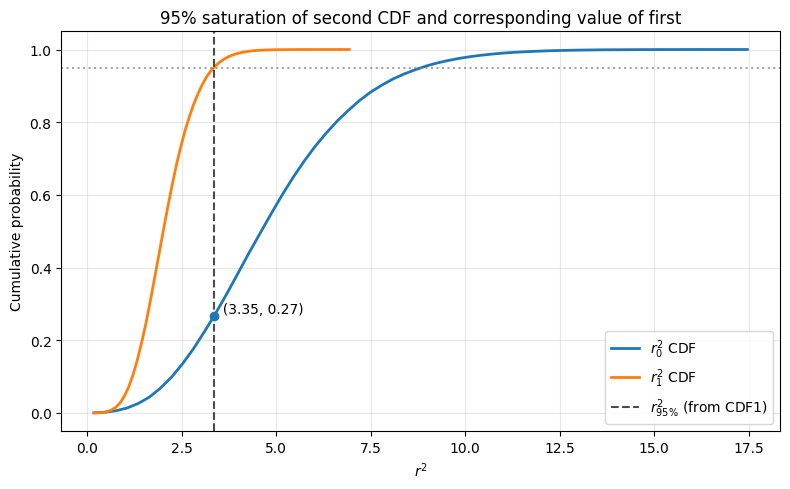

In [3]:
# -----------------------
# 95% saturation point of second CDF
# -----------------------
target = 0.95

# r^2 value where CDF1 reaches 95%
r2_95 = np.interp(target, cdf1, bins1)

# Value of CDF0 at the same r^2
cdf0_at_r2_95 = np.interp(r2_95, bins0, cdf0)

print(f"r^2 at 95% saturation of CDF1: {r2_95:.4f}")
print(f"CDF0 at that r^2: {cdf0_at_r2_95:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(bins0, cdf0, lw=2, label=r"$r_0^2$ CDF")
plt.plot(bins1, cdf1, lw=2, label=r"$r_1^2$ CDF")

plt.axvline(r2_95, color="k", linestyle="--", alpha=0.7, label=r"$r^2_{95\%}$ (from CDF1)")
plt.axhline(0.95, color="gray", linestyle=":", alpha=0.7)

plt.scatter([r2_95], [cdf0_at_r2_95], zorder=5)
plt.text(r2_95, cdf0_at_r2_95,
         f"  ({r2_95:.2f}, {cdf0_at_r2_95:.2f})",
         verticalalignment="bottom")

plt.xlabel(r"$r^2$")
plt.ylabel("Cumulative probability")
plt.title("95% saturation of second CDF and corresponding value of first")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

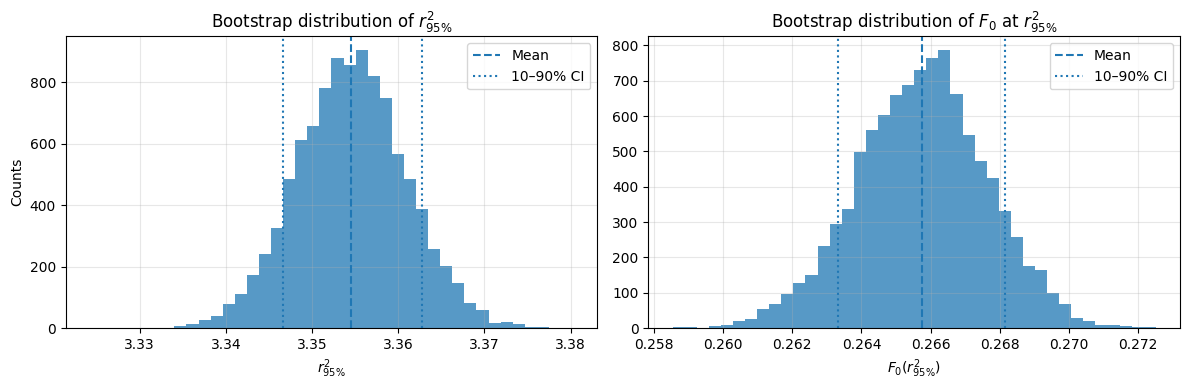

In [4]:
n_boot = int(1e4)
target = 0.95

r2_95_boot = []
cdf0_at_r2_95_boot = []

rng = np.random.default_rng(42)  # reproducible

for i in range(n_boot):
    # -----------------------
    # Bootstrap resampling
    # -----------------------
    r02_boot = rng.choice(r02, size=len(r02), replace=True)
    r12_boot = rng.choice(r12, size=len(r12), replace=True)

    # -----------------------
    # Recompute PDFs
    # -----------------------
    hist0, bins_edges0 = np.histogram(r02_boot, bins=60, density=True)
    bins0 = 0.5 * (bins_edges0[:-1] + bins_edges0[1:])

    hist1, bins_edges1 = np.histogram(r12_boot, bins=60, density=True)
    bins1 = 0.5 * (bins_edges1[:-1] + bins_edges1[1:])

    # -----------------------
    # Recompute CDFs
    # -----------------------
    cdf0 = np.cumsum(hist0)
    cdf0 /= cdf0[-1]

    cdf1 = np.cumsum(hist1)
    cdf1 /= cdf1[-1]

    # -----------------------
    # Interpolate 95% point of CDF1
    # -----------------------
    r2_95 = np.interp(target, cdf1, bins1)

    # Value of CDF0 at same r^2
    cdf0_at_r2_95 = np.interp(r2_95, bins0, cdf0)

    r2_95_boot.append(r2_95)
    cdf0_at_r2_95_boot.append(cdf0_at_r2_95)

r2_95_boot = np.array(r2_95_boot)
cdf0_at_r2_95_boot = np.array(cdf0_at_r2_95_boot)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

# -----------------------
# r^2_95 distribution
# -----------------------
axes[0].hist(r2_95_boot, bins=40, alpha=0.75)
axes[0].axvline(r2_95_boot.mean(), linestyle="--", label="Mean")
axes[0].axvline(np.percentile(r2_95_boot, 10), linestyle=":", label="10–90% CI")
axes[0].axvline(np.percentile(r2_95_boot, 90), linestyle=":")

axes[0].set_xlabel(r"$r^2_{95\%}$")
axes[0].set_ylabel("Counts")
axes[0].set_title(r"Bootstrap distribution of $r^2_{95\%}$")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -----------------------
# CDF0 at r^2_95 distribution
# -----------------------
axes[1].hist(cdf0_at_r2_95_boot, bins=40, alpha=0.75)
axes[1].axvline(cdf0_at_r2_95_boot.mean(), linestyle="--", label="Mean")
axes[1].axvline(np.percentile(cdf0_at_r2_95_boot, 10), linestyle=":", label="10–90% CI")
axes[1].axvline(np.percentile(cdf0_at_r2_95_boot, 90), linestyle=":")

axes[1].set_xlabel(r"$F_0(r^2_{95\%})$")
axes[1].set_title(r"Bootstrap distribution of $F_0$ at $r^2_{95\%}$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()